In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import time
from scipy.stats import binomtest
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [4]:
START_DATE = "2016-01-01"
END_DATE = "2026-01-01"
print(f"Data period: {START_DATE} to {END_DATE}")

Data period: 2016-01-01 to 2026-01-01


In [5]:
# S&P 500 index data
sp500_data = yf.download(
    "^GSPC",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)
sp500_data = sp500_data.reset_index()
if isinstance(sp500_data.columns, pd.MultiIndex):
    sp500_data.columns = sp500_data.columns.get_level_values(0)
sp500_data["Market_Return"] = sp500_data["Close"].pct_change()
market_data = sp500_data[[
    "Date",
    "Market_Return"
]].copy()
market_data["Date"] = pd.to_datetime(market_data["Date"])
print("S&P 500 market data:")
print(f"Rows: {len(market_data):,}")
print(f"Start: {market_data['Date'].min().date()}")
print(f"End: {market_data['Date'].max().date()}")

S&P 500 market data:
Rows: 2,514
Start: 2016-01-04
End: 2025-12-31


In [6]:
# Get current S&P 500 constituents from SPY holdings
spy_holdings_url = (
    "https://www.ssga.com/library-content/products/fund-data/"
    "etfs/us/holdings-daily-us-en-spy.xlsx"
)
spy_holdings = pd.read_excel(
    spy_holdings_url,
    skiprows=4
)
spy_holdings.head()

,Name,Ticker,Identifier,SEDOL,Weight,Sector,Shares Held,Local Currency
0,NVIDIA CORP,NVDA,67066G104,2379504,8.276795,-,292944190.0,USD
1,APPLE INC,AAPL,037833100,2046251,7.409622,-,176664025.0,USD
2,MICROSOFT CORP,MSFT,594918104,2588173,5.525998,-,89886184.0,USD
3,AMAZON.COM INC,AMZN,023135106,2000019,3.740151,-,118821369.0,USD
4,ALPHABET INC CL A,GOOGL,02079K305,BYVY8G0,3.079188,-,71030153.0,USD


In [7]:
# Extract current S&P 500 ticker symbols
tickers = (
    spy_holdings["Ticker"]
    .dropna()
    .astype(str)
    .str.strip()
    .tolist()
)
print(f"Number of tickers: {len(tickers)}")
print("First 10 tickers:", tickers[:10])

Number of tickers: 505
First 10 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'MU', 'TSLA']


In [8]:
# Clean ticker symbols for Yahoo Finance
ticker_mapping = {
    "BRK.B": "BRK-B",
    "BF.B": "BF-B"
}
tickers = [
    ticker_mapping.get(ticker, ticker)
    for ticker in tickers
    if ticker not in ["-", "2602335D"]
]
print(f"Number of cleaned tickers: {len(tickers)}")
print("BRK-B included:", "BRK-B" in tickers)
print("BF-B included:", "BF-B" in tickers)

Number of cleaned tickers: 503
BRK-B included: True
BF-B included: True


In [9]:
# Download historical stock data for current S&P 500 constituents
all_data = {}
failed_tickers = []
batch_size = 50
for i in range(0, len(tickers), batch_size):
    batch = tickers[i:i + batch_size]  
    print(f"Downloading batch {i // batch_size + 1} "
          f"of {int(np.ceil(len(tickers) / batch_size))}...")   
    data = yf.download(
        batch,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        group_by="ticker",
        progress=False,
        threads=True
    )
    for ticker in batch:
        try:
            ticker_data = data[ticker].dropna(how="all")
            if not ticker_data.empty:
                all_data[ticker] = ticker_data
            else:
                failed_tickers.append(ticker)               
        except (KeyError, TypeError):
            failed_tickers.append(ticker)
print("\nDownload complete!")
print(f"Usable tickers: {len(all_data)}")
print(f"Failed tickers: {len(failed_tickers)}")

$HONA: Data doesn't exist for startDate = 1451624400, endDate = 1767243600

1 Failed download:
['HONA']: Data doesn't exist for startDate = 1451624400, endDate = 1767243600


$FDXF: Data doesn't exist for startDate = 1451624400, endDate = 1767243600

1 Failed download:
['FDXF']: Data doesn't exist for startDate = 1451624400, endDate = 1767243600



Download complete!
Usable tickers: 501
Failed tickers: 2


In [10]:
stock_data = []
for ticker, data in all_data.items():
    temp = data.copy()
    if isinstance(temp.columns, pd.MultiIndex):
        temp.columns = temp.columns.get_level_values(-1)
    temp = temp[["Open", "High", "Low", "Close", "Volume"]].copy()
    temp["Ticker"] = ticker
    temp = temp.reset_index()
    stock_data.append(temp)
stock_data = pd.concat(stock_data, ignore_index=True)
stock_data["Date"] = pd.to_datetime(stock_data["Date"])
stock_data = stock_data.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)
print("Master stock dataset:")
print(f"Rows: {len(stock_data):,}")
print(f"Stocks: {stock_data['Ticker'].nunique()}")
print(f"Start date: {stock_data['Date'].min().date()}")
print(f"End date: {stock_data['Date'].max().date()}")
print("\nColumns:")
print(stock_data.columns.tolist())
print("\nFirst 5 rows:")
print(stock_data.head())
stock_data.columns.name = None

Master stock dataset:
Rows: 1,220,262
Stocks: 501
Start date: 2016-01-04
End date: 2025-12-31

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker']

First 5 rows:
Price       Date       Open       High        Low      Close     Volume Ticker
0     2016-01-04  37.751917  37.871441  37.089924  37.411724  3287300.0      A
1     2016-01-05  37.448514  37.650791  37.089936  37.283016  2587200.0      A
2     2016-01-06  36.997997  37.687571  36.823302  37.448517  2103600.0      A
3     2016-01-07  36.906048  36.915244  35.683204  35.857895  3504300.0      A
4     2016-01-08  36.060163  36.510683  35.370588  35.480919  3736700.0      A


In [11]:
horizons = {
    "1D": 1,
    "5D": 5,
    "10D": 10,
    "1M": 21,
    "6M": 126,
    "1Y": 252,
    "5Y": 1260
}
stock_data = stock_data.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)
for horizon_name, days in horizons.items():
    stock_data[f"Return_{horizon_name}"] = (
        stock_data.groupby("Ticker")["Close"].shift(-days)
        / stock_data["Close"]
        - 1
    )
print("Future return targets created:")
for horizon_name in horizons:
    print(f"Return_{horizon_name}")

Future return targets created:
Return_1D
Return_5D
Return_10D
Return_1M
Return_6M
Return_1Y
Return_5Y


In [12]:
print("Non-missing observations by horizon:\n")
for horizon_name in horizons:
    column = f"Return_{horizon_name}"
    count = stock_data[column].notna().sum()  
    print(f"{horizon_name:>3}: {count:,}")

Non-missing observations by horizon:

 1D: 1,219,761
 5D: 1,217,757
10D: 1,215,252
 1M: 1,209,741
 6M: 1,157,216
 1Y: 1,094,246
 5Y: 596,082


In [13]:
# predictor features
stock_data = stock_data.sort_values(
    ["Ticker", "Date"]
).reset_index(drop=True)
grouped = stock_data.groupby("Ticker")
stock_data["Previous_Return"] = grouped["Close"].pct_change()
stock_data["Return_5D_History"] = grouped["Close"].pct_change(5)
stock_data["Return_10D_History"] = grouped["Close"].pct_change(10)
stock_data["Return_20D_History"] = grouped["Close"].pct_change(20)
stock_data["Volatility_20D"] = (
    grouped["Previous_Return"]
    .transform(lambda x: x.rolling(20).std())
)
stock_data["MA_5"] = (
    grouped["Close"]
    .transform(lambda x: x.rolling(5).mean())
)
stock_data["MA_20"] = (
    grouped["Close"]
    .transform(lambda x: x.rolling(20).mean())
)
stock_data["Momentum_20D"] = (
    stock_data["Close"] / stock_data["MA_20"] - 1
)
stock_data["Volume_Change"] = grouped["Volume"].pct_change()
stock_data["Price_to_MA20"] = (
    stock_data["Close"] / stock_data["MA_20"]
)
stock_data = stock_data.merge(
    market_data,
    on="Date",
    how="left"
)
print("Predictor features created.")
feature_columns = [
    "Previous_Return",
    "Return_5D_History",
    "Return_10D_History",
    "Return_20D_History",
    "Volatility_20D",
    "MA_5",
    "MA_20",
    "Momentum_20D",
    "Volume_Change",
    "Price_to_MA20",
    "Market_Return"
]
print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

Predictor features created.

Features:
- Previous_Return
- Return_5D_History
- Return_10D_History
- Return_20D_History
- Volatility_20D
- MA_5
- MA_20
- Momentum_20D
- Volume_Change
- Price_to_MA20
- Market_Return


In [14]:
feature_check = stock_data[feature_columns].isna().sum()
print("Missing values by feature:")
print(feature_check)
print("\nInfinite values:", np.isinf(stock_data[feature_columns]).sum().sum())

Missing values by feature:
Previous_Return         501
Return_5D_History      2505
Return_10D_History     5010
Return_20D_History    10020
Volatility_20D        10020
MA_5                   2004
MA_20                  9519
Momentum_20D           9519
Volume_Change          2359
Price_to_MA20          9519
Market_Return           465
dtype: int64

Infinite values: 884


In [15]:
stock_data = stock_data.replace([np.inf, -np.inf], np.nan)
stock_data = stock_data.dropna(
    subset=feature_columns
).reset_index(drop=True)
print("Data after cleaning:")
print(f"Rows: {len(stock_data):,}")
print(f"Stocks: {stock_data['Ticker'].nunique()}")
print(f"Remaining missing values: {stock_data[feature_columns].isna().sum().sum()}")
print(f"Remaining infinite values: {np.isinf(stock_data[feature_columns]).sum().sum()}")

Data after cleaning:
Rows: 1,207,568
Stocks: 501
Remaining missing values: 0
Remaining infinite values: 0


In [16]:
# training and testing for each horizon
model_data = {}
for horizon_name in horizons:
    target = f"Return_{horizon_name}"
    data = stock_data.dropna(
        subset=[target]
    ).copy()
    data = data.sort_values("Date").reset_index(drop=True)
    unique_dates = data["Date"].sort_values().unique()
    split_index = int(len(unique_dates) * 0.80)
    split_date = unique_dates[split_index]
    train = data[data["Date"] < split_date].copy()
    test = data[data["Date"] >= split_date].copy() 
    X_train = train[feature_columns]
    y_train = train[target]  
    X_test = test[feature_columns]
    y_test = test[target]
    model_data[horizon_name] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
        "train_dates": train["Date"],
        "test_dates": test["Date"],
        "split_date": split_date
    }    
    print(
        f"{horizon_name}: "
        f"Train = {len(train):,}, "
        f"Test = {len(test):,}, "
        f"Split = {pd.Timestamp(split_date).date()}"
    )

1D: Train = 958,144, Test = 248,923, Split = 2024-01-04
5D: Train = 956,657, Test = 248,406, Split = 2023-12-29
10D: Train = 954,675, Test = 247,883, Split = 2023-12-22
1M: Train = 950,214, Test = 246,833, Split = 2023-12-11
6M: Train = 908,644, Test = 235,898, Split = 2023-08-11
1Y: Train = 858,754, Test = 222,838, Split = 2023-03-17
5Y: Train = 464,688, Test = 119,440, Split = 2020-01-03


In [17]:
scalers = {}
for horizon_name in horizons:
    X_train = model_data[horizon_name]["X_train"]
    X_test = model_data[horizon_name]["X_test"]    
    scaler = StandardScaler()    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)    
    model_data[horizon_name]["X_train_scaled"] = X_train_scaled
    model_data[horizon_name]["X_test_scaled"] = X_test_scaled    
    scalers[horizon_name] = scaler
print("Feature scaling complete.")

Feature scaling complete.


In [18]:
# model implementation
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1
    )
}
print("Models defined:")
for model_name in models:
    print("-", model_name)

Models defined:
- Linear Regression
- Random Forest
- XGBoost


In [19]:
# neural network
def build_neural_network(input_size):
    model = Sequential([
        Input(shape=(input_size,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer="adam",
        loss="mse"
    )   
    return model
print("Neural network defined.")

Neural network defined.


In [20]:
# training and testing sets for the neural network
for horizon_name in horizons:
    X_train = model_data[horizon_name]["X_train_scaled"]
    y_train = model_data[horizon_name]["y_train"]
    validation_index = int(len(X_train) * 0.90)
    X_train_nn = X_train[:validation_index]
    y_train_nn = y_train.iloc[:validation_index]
    X_val_nn = X_train[validation_index:]
    y_val_nn = y_train.iloc[validation_index:]
    model_data[horizon_name]["X_train_nn"] = X_train_nn
    model_data[horizon_name]["y_train_nn"] = y_train_nn
    model_data[horizon_name]["X_val_nn"] = X_val_nn
    model_data[horizon_name]["y_val_nn"] = y_val_nn
print("Neural network training and validation sets created.")

Neural network training and validation sets created.


In [21]:
# Train Linear Regression, Random Forest, and XGBoost
results = []
for horizon_name in horizons:
    print(f"\n{'-' * 50}")
    print(f"Training models for {horizon_name}")
    print(f"{'-' * 50}")
    X_train = model_data[horizon_name]["X_train"]
    y_train = model_data[horizon_name]["y_train"]
    X_test = model_data[horizon_name]["X_test"]
    y_test = model_data[horizon_name]["y_test"]
    for model_name, model in models.items():
        # Training time
        start_time = time.perf_counter()
        model.fit(X_train, y_train)
        train_time = time.perf_counter() - start_time
        # Prediction time
        start_time = time.perf_counter()
        predictions = model.predict(X_test)
        predict_time = time.perf_counter() - start_time
        # Performance metrics
        mse = mean_squared_error(y_test, predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)
        # Directional accuracy
        directional_accuracy = np.mean(
            np.sign(y_test.values) == np.sign(predictions)
        )
        results.append({
            "Horizon": horizon_name,
            "Model": model_name,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Directional_Accuracy": directional_accuracy,
            "Training_Time": train_time,
            "Prediction_Time": predict_time
        })
        
        print(
            f"{model_name}: "
            f"RMSE={rmse:.6f}, "
            f"MAE={mae:.6f}, "
            f"R²={r2:.4f}, "
            f"Direction={directional_accuracy:.2%}, "
            f"Train={train_time:.2f}s, "
            f"Predict={predict_time:.2f}s"
        )
print("\nStandard model training complete.")


--------------------------------------------------
Training models for 1D
--------------------------------------------------
Linear Regression: RMSE=0.021168, MAE=0.013473, R²=0.0005, Direction=50.59%, Train=0.59s, Predict=0.01s
Random Forest: RMSE=0.021090, MAE=0.013432, R²=0.0078, Direction=52.40%, Train=396.18s, Predict=0.23s
XGBoost: RMSE=0.021260, MAE=0.013513, R²=-0.0082, Direction=51.56%, Train=3.22s, Predict=0.15s

--------------------------------------------------
Training models for 5D
--------------------------------------------------
Linear Regression: RMSE=0.046304, MAE=0.031526, R²=0.0067, Direction=53.67%, Train=0.23s, Predict=0.02s
Random Forest: RMSE=0.046600, MAE=0.031691, R²=-0.0060, Direction=54.07%, Train=369.69s, Predict=0.25s
XGBoost: RMSE=0.046682, MAE=0.031748, R²=-0.0095, Direction=53.76%, Train=3.35s, Predict=0.14s

--------------------------------------------------
Training models for 10D
--------------------------------------------------
Linear Regression:

In [22]:
# Train the neural network for each prediction horizon
nn_results = []
for horizon_name in horizons:
    print(f"\n{'-' * 50}")
    print(f"Training Neural Network for {horizon_name}")
    print(f"{'-' * 50}")
    X_train = model_data[horizon_name]["X_train_nn"]
    y_train = model_data[horizon_name]["y_train_nn"]
    X_val = model_data[horizon_name]["X_val_nn"]
    y_val = model_data[horizon_name]["y_val_nn"]
    X_test = model_data[horizon_name]["X_test_scaled"]
    y_test = model_data[horizon_name]["y_test"]
    model = build_neural_network(X_train.shape[1])
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=30,
        restore_best_weights=True
    )
    # Training time
    start_time = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=500,
        batch_size=256,
        callbacks=[early_stopping],
        shuffle=False,
        verbose=0
    )
    train_time = time.perf_counter() - start_time
 # Prediction time
    start_time = time.perf_counter()
    predictions = model.predict(X_test, verbose=0).flatten()
    predict_time = time.perf_counter() - start_time
 # calculating MSE, MAE, RMSE, R^2, and Directional Accuracy
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    directional_accuracy = np.mean(
        np.sign(y_test.values) == np.sign(predictions)
    )
    epochs_run = len(history.history["loss"])
    nn_results.append({
        "Horizon": horizon_name,
        "Model": "Neural Network",
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy,
        "Training_Time": train_time,
        "Prediction_Time": predict_time,
        "Epochs": epochs_run
    })
    print(
        f"RMSE={rmse:.6f}, "
        f"MAE={mae:.6f}, "
        f"R²={r2:.4f}, "
        f"Direction={directional_accuracy:.2%}, "
        f"Epochs={epochs_run}, "
        f"Train={train_time:.2f}s, "
        f"Predict={predict_time:.2f}s"
    )

print("\nNeural network training complete.")


--------------------------------------------------
Training Neural Network for 1D
--------------------------------------------------
RMSE=0.021319, MAE=0.013716, R²=-0.0138, Direction=47.82%, Epochs=38, Train=373.25s, Predict=16.50s

--------------------------------------------------
Training Neural Network for 5D
--------------------------------------------------
RMSE=0.047186, MAE=0.032498, R²=-0.0315, Direction=46.47%, Epochs=35, Train=349.92s, Predict=20.63s

--------------------------------------------------
Training Neural Network for 10D
--------------------------------------------------
RMSE=0.068706, MAE=0.048599, R²=-0.0982, Direction=45.31%, Epochs=71, Train=683.15s, Predict=17.90s

--------------------------------------------------
Training Neural Network for 1M
--------------------------------------------------
RMSE=0.100775, MAE=0.070974, R²=-0.0981, Direction=45.44%, Epochs=61, Train=660.69s, Predict=20.76s

--------------------------------------------------
Training Ne

In [23]:
# Combine all results

all_results = pd.DataFrame(results + nn_results)

print("Final model results:")
display(all_results)

Final model results:


,Horizon,Model,MSE,RMSE,MAE,R2,Directional_Accuracy,Training_Time,Prediction_Time,Epochs
0,1D,Linear Regression,0.000448,0.021168,0.013473,0.000528,0.505944,0.587482,0.013884,NaN
1,1D,Random Forest,0.000445,0.021090,0.013432,0.007821,0.523985,396.182320,0.230406,NaN
2,1D,XGBoost,0.000452,0.021260,0.013513,-0.008209,0.515557,3.216735,0.154826,NaN
3,5D,Linear Regression,0.002144,0.046304,0.031526,0.006718,0.536702,0.232796,0.021623,NaN
4,5D,Random Forest,0.002172,0.046600,0.031691,-0.006019,0.540695,369.687166,0.252685,NaN
5,5D,XGBoost,0.002179,0.046682,0.031748,-0.009539,0.537572,3.354975,0.142556,NaN
6,10D,Linear Regression,0.004248,0.065180,0.044992,0.011665,0.552244,0.267350,0.012241,NaN
7,10D,Random Forest,0.004315,0.065690,0.045372,-0.003852,0.552535,387.886401,0.252320,NaN
8,10D,XGBoost,0.004314,0.065680,0.045350,-0.003545,0.545310,3.604547,0.226080,NaN
9,1M,Linear Regression,0.009107,0.095431,0.066485,0.015246,0.562230,0.492589,0.041167,NaN


In [24]:
# zero-return baseline performance
baseline_results = []
for horizon_name in horizons:
    target = f"Return_{horizon_name}"
    data = stock_data.dropna(subset=[target]).copy()
    data = data.sort_values("Date").reset_index(drop=True)
    unique_dates = data["Date"].sort_values().unique()
    split_index = int(len(unique_dates) * 0.80)
    split_date = unique_dates[split_index]
    test = data[data["Date"] >= split_date]
    y_test = test[target]
    # baseline predicts 0%
    predictions = np.zeros(len(y_test))    
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    directional_accuracy = np.mean(
        np.sign(y_test.values) == np.sign(predictions)
    )
    baseline_results.append({
        "Horizon": horizon_name,
        "Model": "Zero-Return Baseline",
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy
    })
    print(
        f"{horizon_name}: "
        f"RMSE={rmse:.6f}, "
        f"MAE={mae:.6f}, "
        f"R²={r2:.4f}"
    )
print("\nBaseline calculation complete.")

1D: RMSE=0.021188, MAE=0.013476, R²=-0.0014
5D: RMSE=0.046621, MAE=0.031758, R²=-0.0069
10D: RMSE=0.065998, MAE=0.045526, R²=-0.0133
1M: RMSE=0.097489, MAE=0.067293, R²=-0.0277
6M: RMSE=0.309581, MAE=0.191203, R²=-0.1494
1Y: RMSE=0.552596, MAE=0.310433, R²=-0.1893
5Y: RMSE=2.326716, MAE=1.388117, R²=-0.4725

Baseline calculation complete.


In [25]:
# Combine model results with the zero-return baseline
baseline_df = pd.DataFrame(baseline_results)
comparison_results = pd.concat(
    [
        all_results,
        baseline_df
    ],
    ignore_index=True
)
print("Complete comparison dataset:")
display(comparison_results)

Complete comparison dataset:


,Horizon,Model,MSE,RMSE,MAE,R2,Directional_Accuracy,Training_Time,Prediction_Time,Epochs
0,1D,Linear Regression,0.000448,0.021168,0.013473,0.000528,0.505944,0.587482,0.013884,NaN
1,1D,Random Forest,0.000445,0.021090,0.013432,0.007821,0.523985,396.182320,0.230406,NaN
2,1D,XGBoost,0.000452,0.021260,0.013513,-0.008209,0.515557,3.216735,0.154826,NaN
3,5D,Linear Regression,0.002144,0.046304,0.031526,0.006718,0.536702,0.232796,0.021623,NaN
4,5D,Random Forest,0.002172,0.046600,0.031691,-0.006019,0.540695,369.687166,0.252685,NaN
5,5D,XGBoost,0.002179,0.046682,0.031748,-0.009539,0.537572,3.354975,0.142556,NaN
6,10D,Linear Regression,0.004248,0.065180,0.044992,0.011665,0.552244,0.267350,0.012241,NaN
7,10D,Random Forest,0.004315,0.065690,0.045372,-0.003852,0.552535,387.886401,0.252320,NaN
8,10D,XGBoost,0.004314,0.065680,0.045350,-0.003545,0.545310,3.604547,0.226080,NaN
9,1M,Linear Regression,0.009107,0.095431,0.066485,0.015246,0.562230,0.492589,0.041167,NaN


In [26]:
# best model at each prediction horizon
model_results = comparison_results[
    comparison_results["Model"] != "Zero-Return Baseline"
].copy()
baseline_only = comparison_results[
    comparison_results["Model"] == "Zero-Return Baseline"
][["Horizon", "RMSE"]].rename(
    columns={"RMSE": "Baseline_RMSE"}
)
# Which model with the lowest RMSE for each horizon
best_models = (
    model_results.loc[
        model_results.groupby("Horizon")["RMSE"].idxmin()
    ]
    .copy()
)
# Zero-return baseline RMSE
best_models = best_models.merge(
    baseline_only,
    on="Horizon"
)
# Percent improvement over the zero-return baseline
best_models["Baseline_Improvement_%"] = (
    (best_models["Baseline_RMSE"] - best_models["RMSE"])
    / best_models["Baseline_RMSE"]
    * 100
)
# Main results
best_models[
    [
        "Horizon",
        "Model",
        "RMSE",
        "MAE",
        "R2",
        "Directional_Accuracy",
        "Training_Time",
        "Prediction_Time",
        "Baseline_RMSE",
        "Baseline_Improvement_%"
    ]
]

,Horizon,Model,RMSE,MAE,R2,Directional_Accuracy,Training_Time,Prediction_Time,Baseline_RMSE,Baseline_Improvement_%
0,10D,Linear Regression,0.065180,0.044992,0.011665,0.552244,0.267350,0.012241,0.065998,1.238914
1,1D,Random Forest,0.021090,0.013432,0.007821,0.523985,396.182320,0.230406,0.021188,0.459210
2,1M,Linear Regression,0.095431,0.066485,0.015246,0.562230,0.492589,0.041167,0.097489,2.110761
3,1Y,XGBoost,0.483985,0.273902,0.087684,0.714501,4.210774,0.158337,0.552596,12.416215
4,5D,Linear Regression,0.046304,0.031526,0.006718,0.536702,0.232796,0.021623,0.046621,0.680149
5,5Y,XGBoost,1.782764,1.090491,0.135541,0.870538,1.995519,0.072172,2.326716,23.378526
6,6M,Linear Regression,0.282284,0.176785,0.044362,0.667962,0.456867,0.039619,0.309581,8.817338


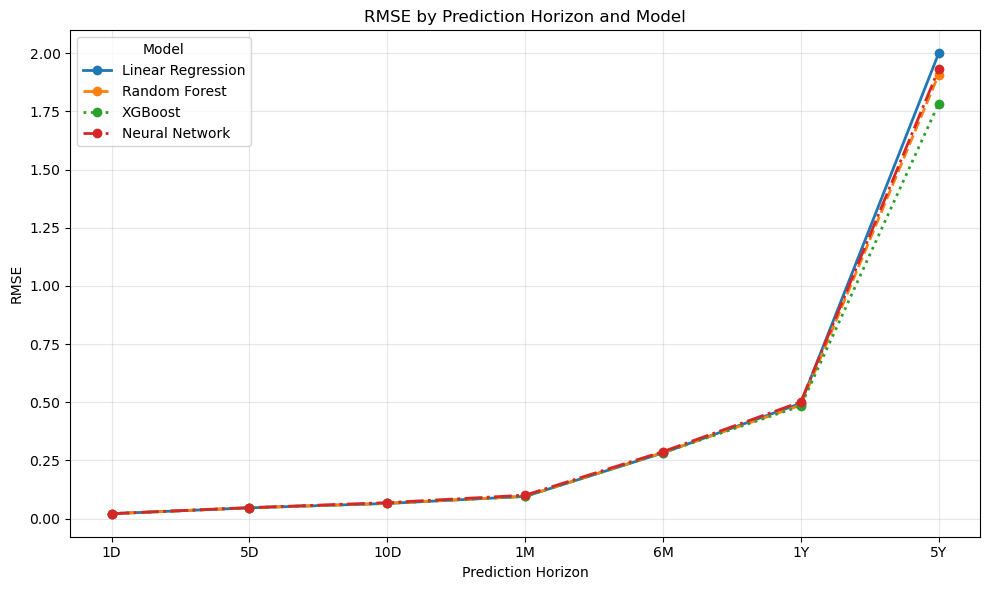

In [27]:
# Plot RMSE across prediction horizons
horizon_order = ["1D", "5D", "10D", "1M", "6M", "1Y", "5Y"]
plot_data = comparison_results[
    comparison_results["Model"] != "Zero-Return Baseline"
].copy()
plot_data["Horizon"] = pd.Categorical(
    plot_data["Horizon"],
    categories=horizon_order,
    ordered=True
)
line_styles = {
    "Linear Regression": "-",
    "Random Forest": "--",
    "XGBoost": ":",
    "Neural Network": "-."
}
plt.figure(figsize=(10, 6))
for model in plot_data["Model"].unique():
    model_data = plot_data[plot_data["Model"] == model].sort_values("Horizon")
    plt.plot(
        model_data["Horizon"],
        model_data["RMSE"],
        marker="o",
        linestyle=line_styles.get(model, "-"),
        linewidth=2,
        label=model
    )
plt.xlabel("Prediction Horizon")
plt.ylabel("RMSE")
plt.title("RMSE by Prediction Horizon and Model")
plt.legend(title="Model")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

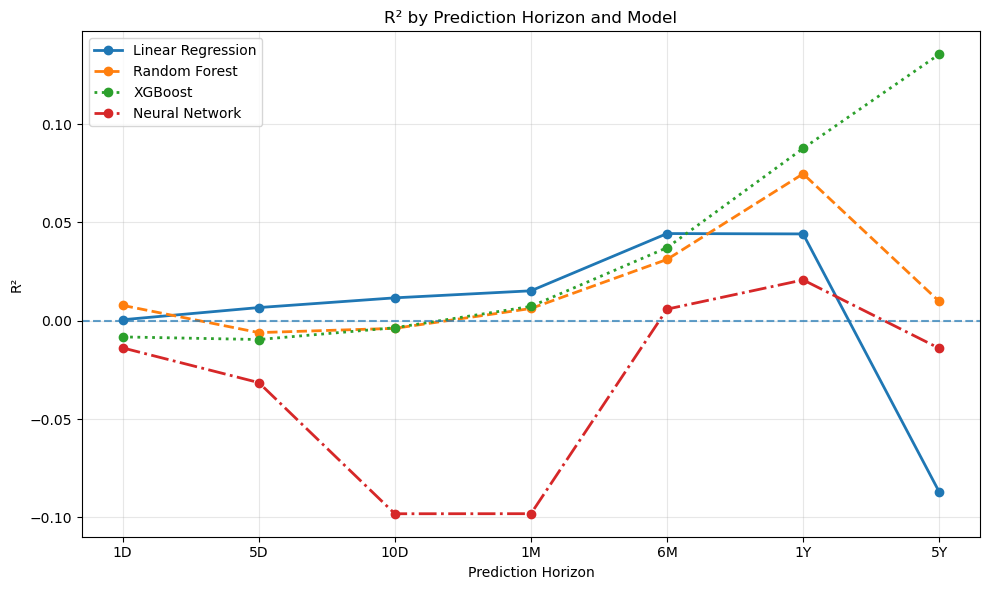

In [28]:
# Plot R² across prediction horizons
plot_data = comparison_results[
    comparison_results["Model"] != "Zero-Return Baseline"
].copy()
plot_data["Horizon"] = pd.Categorical(
    plot_data["Horizon"],
    categories=horizon_order,
    ordered=True
)
line_styles = {
    "Linear Regression": "-",
    "Random Forest": "--",
    "XGBoost": ":",
    "Neural Network": "-."
}
plt.figure(figsize=(10, 6))
for model in plot_data["Model"].unique():
    model_data = plot_data[
        plot_data["Model"] == model
    ].sort_values("Horizon")
    plt.plot(
        model_data["Horizon"],
        model_data["R2"],
        marker="o",
        linestyle=line_styles.get(model, "-"),
        linewidth=2,
        label=model
    )
plt.axhline(0, linestyle="--", alpha=0.7)
plt.xlabel("Prediction Horizon")
plt.ylabel("R²")
plt.title("R² by Prediction Horizon and Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

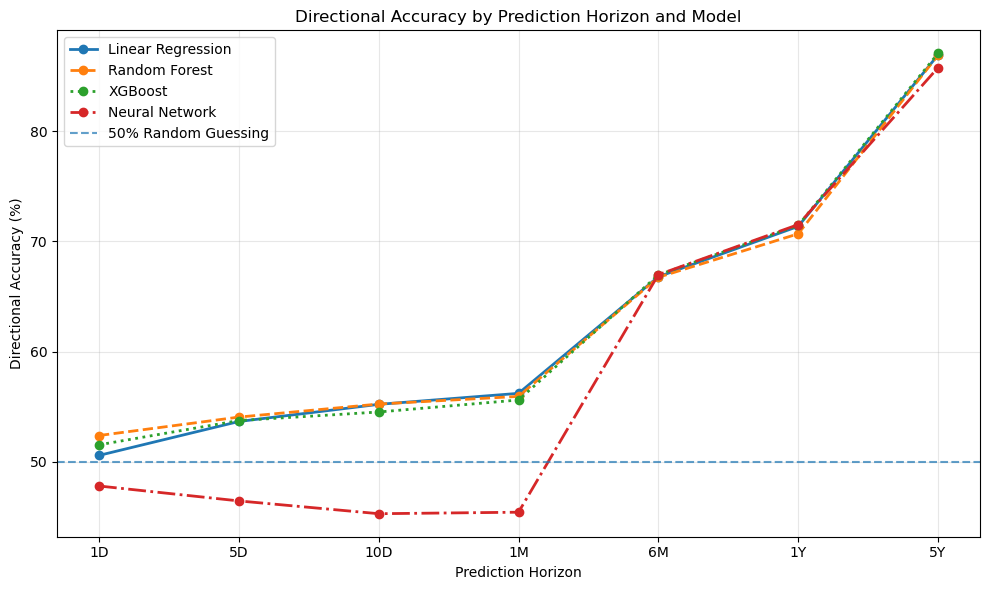

In [29]:
# Plot directional accuracy across prediction horizons
plot_data = comparison_results[
    comparison_results["Model"] != "Zero-Return Baseline"
].copy()
plot_data["Horizon"] = pd.Categorical(
    plot_data["Horizon"],
    categories=horizon_order,
    ordered=True
)
line_styles = {
    "Linear Regression": "-",
    "Random Forest": "--",
    "XGBoost": ":",
    "Neural Network": "-."
}
plt.figure(figsize=(10, 6))
for model in plot_data["Model"].unique():
    model_data = plot_data[
        plot_data["Model"] == model
    ].sort_values("Horizon")
    plt.plot(
        model_data["Horizon"],
        model_data["Directional_Accuracy"] * 100,
        marker="o",
        linestyle=line_styles.get(model, "-"),
        linewidth=2,
        label=model
    )
plt.axhline(
    50,
    linestyle="--",
    alpha=0.7,
    label="50% Random Guessing"
)
plt.xlabel("Prediction Horizon")
plt.ylabel("Directional Accuracy (%)")
plt.title("Directional Accuracy by Prediction Horizon and Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

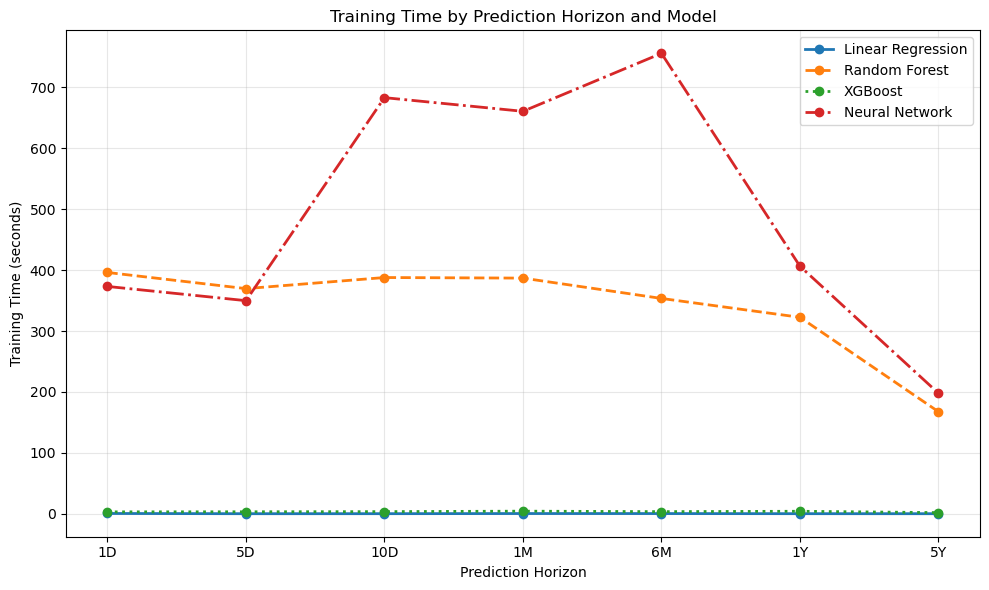

In [30]:
# Plot training time by prediction horizon and model
plot_data = comparison_results[
    comparison_results["Model"] != "Zero-Return Baseline"
].copy()
plot_data["Horizon"] = pd.Categorical(
    plot_data["Horizon"],
    categories=horizon_order,
    ordered=True
)
line_styles = {
    "Linear Regression": "-",
    "Random Forest": "--",
    "XGBoost": ":",
    "Neural Network": "-."
}
plt.figure(figsize=(10, 6))
for model in plot_data["Model"].unique():
    model_data = plot_data[
        plot_data["Model"] == model
    ].sort_values("Horizon")
    plt.plot(
        model_data["Horizon"],
        model_data["Training_Time"],
        marker="o",
        linestyle=line_styles.get(model, "-"),
        linewidth=2,
        label=model
    )
plt.xlabel("Prediction Horizon")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time by Prediction Horizon and Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

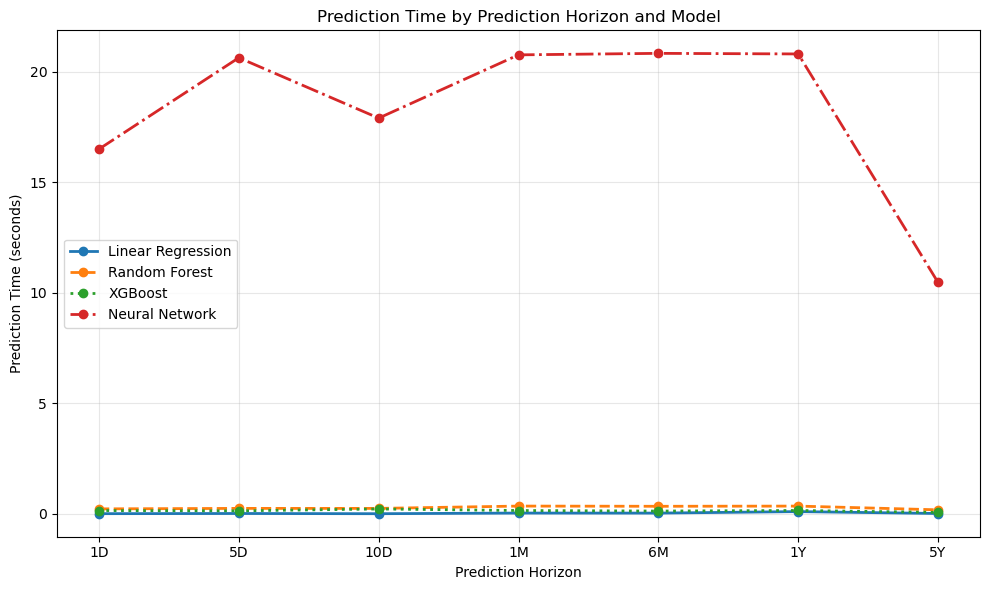

In [31]:
# Plot prediction time by prediction horizon and model
plot_data = comparison_results[
    comparison_results["Model"] != "Zero-Return Baseline"
].copy()
plot_data["Horizon"] = pd.Categorical(
    plot_data["Horizon"],
    categories=horizon_order,
    ordered=True
)
line_styles = {
    "Linear Regression": "-",
    "Random Forest": "--",
    "XGBoost": ":",
    "Neural Network": "-."
}
plt.figure(figsize=(10, 6))
for model in plot_data["Model"].unique():
    model_data = plot_data[
        plot_data["Model"] == model
    ].sort_values("Horizon")
    plt.plot(
        model_data["Horizon"],
        model_data["Prediction_Time"],
        marker="o",
        linestyle=line_styles.get(model, "-"),
        linewidth=2,
        label=model
    )
plt.xlabel("Prediction Horizon")
plt.ylabel("Prediction Time (seconds)")
plt.title("Prediction Time by Prediction Horizon and Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
# Is each model's directional accuracy different from 50%
directional_results = []
models_to_test = comparison_results[
    comparison_results["Model"] != "Zero-Return Baseline"
].copy()

for horizon_name in horizons:
    target = f"Return_{horizon_name}"
    data = stock_data.dropna(
        subset=feature_columns + [target]
    ).copy()
    
    data = data.sort_values("Date").reset_index(drop=True)
    unique_dates = data["Date"].sort_values().unique()
    split_index = int(len(unique_dates) * 0.80)
    split_date = unique_dates[split_index]
    
    test = data[data["Date"] >= split_date]
    n = len(test)
    horizon_results = models_to_test[
        models_to_test["Horizon"] == horizon_name
    ]
    
    for _, row in horizon_results.iterrows():
        model = row["Model"]
        accuracy = row["Directional_Accuracy"]
        successes = round(accuracy * n)
        test_result = binomtest(
            successes,
            n=n,
            p=0.50,
            alternative="two-sided"
        )
        
        directional_results.append({
            "Horizon": horizon_name,
            "Model": model,
            "Directional_Accuracy": accuracy,
            "N": n,
            "p_value": test_result.pvalue
        })

directional_tests = pd.DataFrame(directional_results)
directional_tests["Significant_at_0.05"] = (
    directional_tests["p_value"] < 0.05
)

display(directional_tests)

,Horizon,Model,Directional_Accuracy,N,p_value,Significant_at_0.05
0,1D,Linear Regression,0.505944,248923,3.050596e-09,True
1,1D,Random Forest,0.523985,248923,1.286904e-126,True
2,1D,XGBoost,0.515557,248923,2.435200e-54,True
3,1D,Neural Network,0.478220,248923,9.727730e-105,True
4,5D,Linear Regression,0.536702,248406,2.939046e-293,True
5,5D,Random Forest,0.540695,248406,0.000000e+00,True
6,5D,XGBoost,0.537572,248406,3.149534e-307,True
7,5D,Neural Network,0.464691,248406,1.455273e-271,True
8,10D,Linear Regression,0.552244,247883,0.000000e+00,True
9,10D,Random Forest,0.552535,247883,0.000000e+00,True


In [33]:
print(results[0].keys())
print(nn_results[0].keys())

dict_keys(['Horizon', 'Model', 'MSE', 'RMSE', 'MAE', 'R2', 'Directional_Accuracy', 'Training_Time', 'Prediction_Time'])
dict_keys(['Horizon', 'Model', 'MSE', 'RMSE', 'MAE', 'R2', 'Directional_Accuracy', 'Training_Time', 'Prediction_Time', 'Epochs'])


In [34]:
# Compare neural network loss functions for the 1D horizon
horizon_name = "1D"
target = f"Return_{horizon_name}"
data = stock_data.dropna(
    subset=feature_columns + [target]
).copy()

data = data.sort_values("Date").reset_index(drop=True)

unique_dates = data["Date"].sort_values().unique()
split_index = int(len(unique_dates) * 0.80)
split_date = unique_dates[split_index]

train = data[data["Date"] < split_date]
test = data[data["Date"] >= split_date]

X_train = train[feature_columns]
y_train = train[target]

X_test = test[feature_columns]
y_test = test[target]

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
validation_index = int(len(X_train_scaled) * 0.90)

X_train_nn = X_train_scaled[:validation_index]
y_train_nn = y_train.iloc[:validation_index]

X_val_nn = X_train_scaled[validation_index:]
y_val_nn = y_train.iloc[validation_index:]
def build_nn_with_loss(input_size, loss_function):
    model = Sequential([
        Input(shape=(input_size,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    
    model.compile(
        optimizer="adam",
        loss=loss_function
    )
    
    return model
loss_functions = {
    "MSE": "mse",
    "MAE": "mae",
    "Huber": tf.keras.losses.Huber()
}

loss_results = []

for loss_name, loss_function in loss_functions.items():
    
    print(f"\nTraining Neural Network with {loss_name} loss...")
    
    model = build_nn_with_loss(
        X_train_nn.shape[1],
        loss_function
    )
    
    start_time = time.time()
    
    history = model.fit(
        X_train_nn,
        y_train_nn,
        validation_data=(X_val_nn, y_val_nn),
        epochs=500,
        batch_size=256,
        shuffle=False,
        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=30,
                restore_best_weights=True
            )
        ],
        verbose=0
    )
    
    training_time = time.time() - start_time
    
    start_time = time.time()
    
    predictions = model.predict(
        X_test_scaled,
        verbose=0
    ).flatten()
    
    prediction_time = time.time() - start_time
    
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    directional_accuracy = np.mean(
        np.sign(y_test.values) == np.sign(predictions)
    )
    
    loss_results.append({
        "Horizon": horizon_name,
        "Loss_Function": loss_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy,
        "Training_Time": training_time,
        "Prediction_Time": prediction_time,
        "Epochs": len(history.history["loss"])
    })

loss_comparison = pd.DataFrame(loss_results)

display(loss_comparison)


Training Neural Network with MSE loss...

Training Neural Network with MAE loss...

Training Neural Network with Huber loss...


,Horizon,Loss_Function,MSE,RMSE,MAE,R2,Directional_Accuracy,Training_Time,Prediction_Time,Epochs
0,1D,MSE,0.000454,0.021313,0.013647,-0.013288,0.472982,454.846312,20.658421,41
1,1D,MAE,0.000453,0.021289,0.013570,-0.010985,0.473387,368.733174,20.688759,32
2,1D,Huber,0.000455,0.021333,0.013718,-0.015147,0.480165,383.977085,20.642085,37


In [35]:
# best-model summary

final_summary = best_models[
    [
        "Horizon",
        "Model",
        "RMSE",
        "MAE",
        "R2",
        "Directional_Accuracy",
        "Training_Time",
        "Prediction_Time",
        "Baseline_RMSE",
        "Baseline_Improvement_%"
    ]
].copy()

# Put horizons in the correct order
final_summary["Horizon"] = pd.Categorical(
    final_summary["Horizon"],
    categories=["1D", "5D", "10D", "1M", "6M", "1Y", "5Y"],
    ordered=True
)

final_summary = final_summary.sort_values("Horizon")

display(final_summary)

,Horizon,Model,RMSE,MAE,R2,Directional_Accuracy,Training_Time,Prediction_Time,Baseline_RMSE,Baseline_Improvement_%
1,1D,Random Forest,0.021090,0.013432,0.007821,0.523985,396.182320,0.230406,0.021188,0.459210
4,5D,Linear Regression,0.046304,0.031526,0.006718,0.536702,0.232796,0.021623,0.046621,0.680149
0,10D,Linear Regression,0.065180,0.044992,0.011665,0.552244,0.267350,0.012241,0.065998,1.238914
2,1M,Linear Regression,0.095431,0.066485,0.015246,0.562230,0.492589,0.041167,0.097489,2.110761
6,6M,Linear Regression,0.282284,0.176785,0.044362,0.667962,0.456867,0.039619,0.309581,8.817338
3,1Y,XGBoost,0.483985,0.273902,0.087684,0.714501,4.210774,0.158337,0.552596,12.416215
5,5Y,XGBoost,1.782764,1.090491,0.135541,0.870538,1.995519,0.072172,2.326716,23.378526
